In [1]:
# ============================================
# Superstore Sales Analysis
# Business Analyst Portfolio Project
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# Load the dataset
df = pd.read_csv('C:/Users/Karthick/Desktop/Superstore Sales Analysis/Data/Sample - Superstore.csv', encoding='latin-1')

In [4]:
# First look
print("Shape:", df.shape)


Shape: (9994, 21)


In [5]:
print("\nColumns:", df.columns.tolist())


Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [8]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
# ============================================
# STEP 1: Data Quality Check
# ============================================

print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== DUPLICATES ===")
print("Duplicate rows:", df.duplicated().sum())

=== MISSING VALUES ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

=== DATA TYPES ===
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

=== D

In [10]:
# ============================================
# STEP 2: Fix Data Types
# ============================================

# Convert dates from string to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract useful time columns (BAs use these for trend analysis)
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')  # Jan, Feb...

# Verify
print("Date range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("Years in data:", sorted(df['Order Year'].unique()))
print("\nUpdated dtypes:")
print(df[['Order Date', 'Ship Date', 'Order Year', 'Order Month']].dtypes)

Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00
Years in data: [2014, 2015, 2016, 2017]

Updated dtypes:
Order Date     datetime64[ns]
Ship Date      datetime64[ns]
Order Year              int32
Order Month             int32
dtype: object


In [11]:
# ============================================
# BUSINESS QUESTION 1: Region Performance
# ============================================

region_perf = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique'),
    Avg_Discount=('Discount', 'mean')
).round(2)



In [12]:
region_perf

,Total_Sales,Total_Profit,Total_Orders,Avg_Discount
Region,,,,
Central,501239.89,39706.36,1175,0.24
East,678781.24,91522.78,1401,0.15
South,391721.90,46749.43,822,0.15
West,725457.82,108418.45,1611,0.11


In [13]:
# Add profit margin column
region_perf['Profit_Margin_%'] = (
    (region_perf['Total_Profit'] / region_perf['Total_Sales']) * 100
).round(2)

In [14]:
region_perf = region_perf.sort_values('Profit_Margin_%', ascending=False)
print(region_perf)

         Total_Sales  Total_Profit  Total_Orders  Avg_Discount  \
Region                                                           
West       725457.82     108418.45          1611          0.11   
East       678781.24      91522.78          1401          0.15   
South      391721.90      46749.43           822          0.15   
Central    501239.89      39706.36          1175          0.24   

         Profit_Margin_%  
Region                    
West               14.94  
East               13.48  
South              11.93  
Central             7.92  


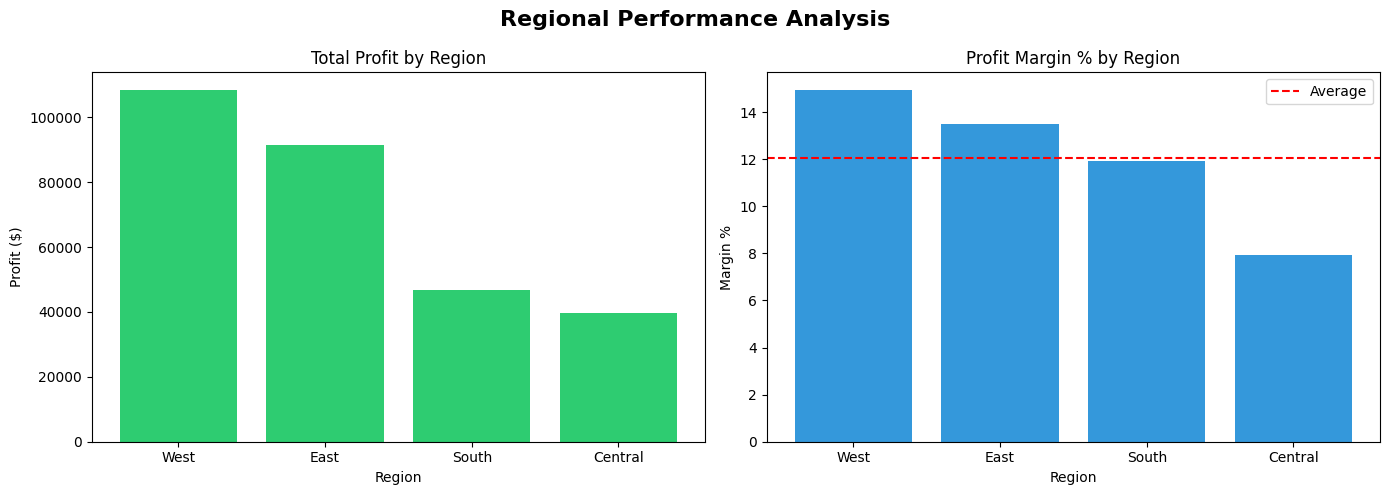

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regional Performance Analysis', fontsize=16, fontweight='bold')

# Chart 1: Profit by Region
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in region_perf['Total_Profit']]
axes[0].bar(region_perf.index, region_perf['Total_Profit'], color=colors)
axes[0].set_title('Total Profit by Region')
axes[0].set_ylabel('Profit ($)')
axes[0].set_xlabel('Region')

# Chart 2: Profit Margin by Region
axes[1].bar(region_perf.index, region_perf['Profit_Margin_%'], color='#3498db')
axes[1].set_title('Profit Margin % by Region')
axes[1].set_ylabel('Margin %')
axes[1].set_xlabel('Region')
axes[1].axhline(y=region_perf['Profit_Margin_%'].mean(), 
                color='red', linestyle='--', label='Average')
axes[1].legend()

plt.tight_layout()
plt.savefig('C:/Users/Karthick/Desktop/Superstore Sales Analysis/Reports/01_region_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ============================================
# BUSINESS QUESTION 2: Category Performance
# ============================================

category_perf = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean')
).round(2)

category_perf['Profit_Margin_%'] = (
    (category_perf['Total_Profit'] / category_perf['Total_Sales']) * 100
).round(2)

print(category_perf.sort_values('Profit_Margin_%'))

# Sub-category breakdown (more granular)
print("\n=== SUB-CATEGORY PROFIT (Bottom 5) ===")
subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values()
print(subcat.head(5))  # worst performing

                 Total_Sales  Total_Profit  Avg_Discount  Profit_Margin_%
Category                                                                 
Furniture          741999.80      18451.27          0.17             2.49
Office Supplies    719047.03     122490.80          0.16            17.04
Technology         836154.03     145454.95          0.13            17.40

=== SUB-CATEGORY PROFIT (Bottom 5) ===
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64


Correlation between Discount and Profit: -0.219
(Closer to -1 means higher discount = lower profit)


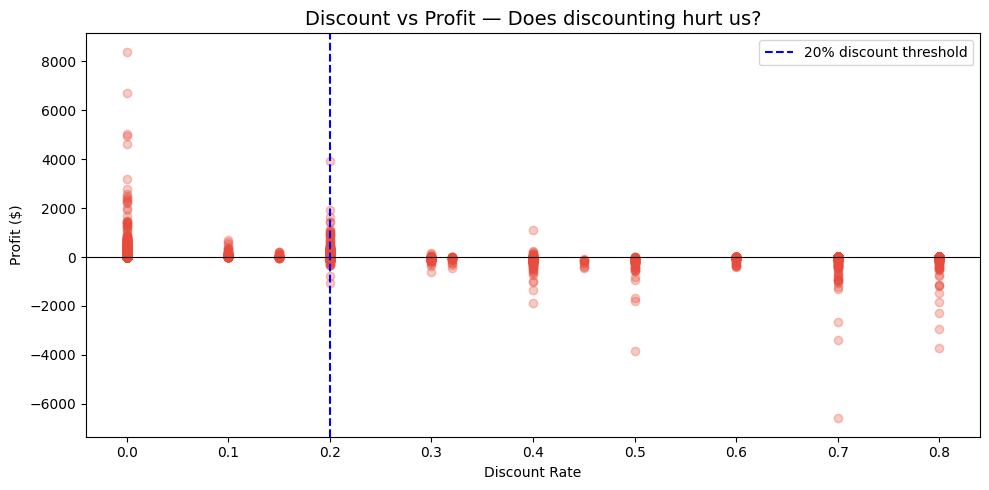


=== Avg Profit by Discount Level ===
Discount_Bucket
No Discount     66.90
1-20%           26.50
21-40%         -77.86
41-60%        -134.62
61%+           -98.35
Name: Profit, dtype: float64


In [20]:
# ============================================
# BUSINESS QUESTION 3: Discount vs Profit
# ============================================

# Correlation check
correlation = df['Discount'].corr(df['Profit'])
print(f"Correlation between Discount and Profit: {correlation:.3f}")
print("(Closer to -1 means higher discount = lower profit)")

# Scatter plot
plt.figure(figsize=(10, 5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='#e74c3c')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.axvline(x=0.2, color='blue', linestyle='--', label='20% discount threshold')
plt.title('Discount vs Profit — Does discounting hurt us?', fontsize=14)
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.legend()
plt.tight_layout()
plt.savefig('C:/Users/Karthick/Desktop/Superstore Sales Analysis/Reports/02_discount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()

# Bucket discounts and see average profit per bucket
df['Discount_Bucket'] = pd.cut(df['Discount'], 
                                bins=[-0.01, 0, 0.2, 0.4, 0.6, 0.9],
                                labels=['No Discount', '1-20%', '21-40%', '41-60%', '61%+'])

print("\n=== Avg Profit by Discount Level ===")
print(df.groupby('Discount_Bucket', observed=True)['Profit'].mean().round(2))

In [21]:
# ============================================
# SAVE CLEAN DATA FOR SQL
# ============================================

df.to_csv('C:/Users/Karthick/Desktop/Superstore Sales Analysis/Data/superstore_clean.csv', index=False)
print("Clean dataset saved!")
print("Shape:", df.shape)
print("New columns added:", ['Order Year', 'Order Month', 'Order Month Name', 'Discount_Bucket'])

Clean dataset saved!
Shape: (9994, 25)
New columns added: ['Order Year', 'Order Month', 'Order Month Name', 'Discount_Bucket']
